In [44]:
import matplotlib.pyplot as plt
import torch 
import pandas as pd

from model_zoo.configs import *
from model_zoo.vit_homemade import ViT
from model_zoo.covit import CoViT

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 

vit_homemade_conf_dict = {}
covit_conf_dict = {}

vit_homemade_dict = {}
covit_dict = {}

vit_homemade_conf_dict['vit_D1_E512_H1_R224_P16'] = vit_D1_E512_H1_R224_P16
#vit_homemade_conf_dict['vit_D1_E512_H4_R224_P16'] = vit_D1_E512_H4_R224_P16
#vit_homemade_conf_dict['vit_D4_E512_H1_R224_P16'] = vit_D4_E512_H1_R224_P16
#vit_homemade_conf_dict['vit_D4_E512_H4_R224_P16'] = vit_D4_E512_H4_R224_P16
#vit_homemade_conf_dict['vit_D8_E512_H1_R224_P16'] = vit_D8_E512_H1_R224_P16
#vit_homemade_conf_dict['vit_D8_E512_H4_R224_P16'] = vit_D8_E512_H4_R224_P16
#vit_homemade_conf_dict['vit_D8_E512_H4_R224_P32'] = vit_D8_E512_H4_R224_P32
#vit_homemade_conf_dict['vit_D12_E512_H8_R224_P32'] = vit_D12_E512_H8_R224_P32


covit_conf_dict['covit_D1_E512_K3_R224_P16'] = covit_D1_E512_K3_R224_P16
#covit_conf_dict['covit_D1_E512_K3333_R224_P16'] = covit_D1_E512_K3333_R224_P16
#covit_conf_dict['covit_D4_E512_K3_R224_P16'] = covit_D4_E512_K3_R224_P16
#covit_conf_dict['covit_D4_E512_K3333_R224_P16'] = covit_D4_E512_K3333_R224_P16
#covit_conf_dict['covit_D4_E512_K7777_R224_P16'] = covit_D4_E512_K7777_R224_P16
#covit_conf_dict['covit_D8_E512_K3_R224_P16'] = covit_D8_E512_K3_R224_P16
#covit_conf_dict['covit_D8_E512_K1357_R224_P16'] = covit_D8_E512_K1357_R224_P16
#covit_conf_dict['covit_D8_E512_K3333_R224_P16'] = covit_D8_E512_K3333_R224_P16
#covit_conf_dict['covit_D8_E512_K7777_R224_P16'] = covit_D8_E512_K7777_R224_P16
#covit_conf_dict['covit_D8_E512_K3333_R224_P32'] = covit_D8_E512_K3333_R224_P32
#covit_conf_dict['covit_D12_E512_4xK3_4xK5_R224_P32'] = covit_D12_E512_4xK3_4xK5_R224_P32
#covit_conf_dict['covit_D16_E512_4xK3_4xK5_R224_P32'] = covit_D16_E512_4xK3_4xK5_R224_P32


for net_name, conf in vit_homemade_conf_dict.items():
    vit_homemade_dict[net_name] = ViT(
                                    in_channels=conf['embedding']['in_channels'],
                                    patch_size=conf['embedding']['patch_size'],
                                    em_size=conf['embedding']['em_size'],
                                    img_size=conf['embedding']['img_size'],
                                    depth=conf['encoder']['depth'],
                                    n_classes=conf['cls_head']['n_classes'],
                                    forward_expansion = conf['encoder']['MLP_expansion'],
                                    forward_drop_out = conf['encoder']['MLP_drop_out'],
                                    d_K = conf['encoder']['d_K'],
                                    d_V = conf['encoder']['d_V'],
                                    num_heads = conf['encoder']['num_heads'],
                                    drop_out = conf['encoder']['att_drop_out']
                                    ) 

for net_name, conf in covit_conf_dict.items():
    covit_dict[net_name] = CoViT(
                                    in_channels=conf['embedding']['in_channels'],
                                    patch_size=conf['embedding']['patch_size'],
                                    em_size=conf['embedding']['em_size'],
                                    img_size=conf['embedding']['img_size'],
                                    depth=conf['encoder']['depth'],
                                    n_classes=conf['cls_head']['n_classes'],
                                    forward_expansion = conf['encoder']['MLP_expansion'],
                                    forward_drop_out = conf['encoder']['MLP_drop_out'],
                                    kernel_size_group = conf['encoder']['kernel_size_group'],
                                    stride_group = conf['encoder']['stride_group'],
                                    padding_group = conf['encoder']['padding_group'],
                                    ) 
net_dict = {}
net_dict.update(vit_homemade_dict)
net_dict.update(covit_dict)

In [45]:
df_elder = pd.DataFrame()
for net_name, net in net_dict.items():
    df_tot = pd.read_csv(f'./log_zoo/singular_val_estimation/cifar10/{net_name}_epoch{150}.csv')
    df_old = pd.DataFrame()
    for i in range(1,((df_tot.shape[1]-1)//3 + 1)):
        df_new = pd.DataFrame(df_tot, columns=[f'F-layer{i}', f'L_infty-layer{i}', f'L_1-layer{i}'])
        df_new = df_new.rename(columns={f'F-layer{i}':'F', f'L_infty-layer{i}':'L_infty', f'L_1-layer{i}':'L_1'})
        tmp = (df_new['L_infty']*df_new['L_1'])**(0.5)
        df_new.insert(3, 'estimation', tmp)
        df_new.insert(0, 'layer', f'layer{i}')  
        df_old = pd.concat([df_old, df_new], ignore_index=True)

    df_old.insert(0, 'net_name', net_name)
    df_elder = pd.concat([df_elder, df_old], ignore_index=True)

In [47]:
df_elder

,net_name,layer,F,L_infty,L_1,estimation
0,vit_D1_E512_H1_R224_P16,layer1,429.803131,1657.434448,786.036194,1141.404164
1,vit_D1_E512_H1_R224_P16,layer1,429.803131,1657.434448,786.036194,1141.404164
2,vit_D1_E512_H1_R224_P16,layer1,432.718414,1526.935303,611.420776,966.229770
3,vit_D1_E512_H1_R224_P16,layer1,432.029053,885.058899,654.346619,761.009394
4,vit_D1_E512_H1_R224_P16,layer1,464.148407,792.738037,734.585938,763.108258
...,...,...,...,...,...,...
61,covit_D1_E512_K3_R224_P16,layer1,502.194611,731.413330,101.202194,272.067333
62,covit_D1_E512_K3_R224_P16,layer1,429.877747,597.178772,97.602966,241.425805
63,covit_D1_E512_K3_R224_P16,layer1,468.834930,646.868347,102.234444,257.161867
64,covit_D1_E512_K3_R224_P16,layer1,391.928833,464.671967,74.469582,186.021308


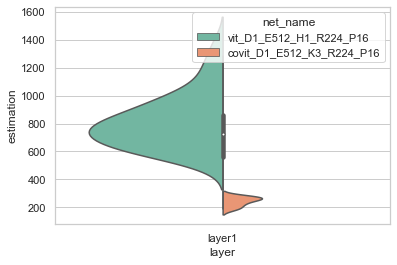

In [48]:
import seaborn as sns
sns.set_theme(style="whitegrid")
tips = sns.load_dataset("tips")

ax = sns.violinplot(x="layer", y="estimation", hue="net_name",
                    data=df_elder, palette="Set2", split=True,
                    scale="count")


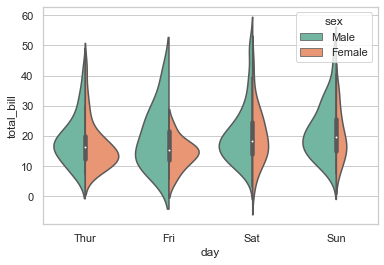

In [6]:
import seaborn as sns
sns.set_theme(style="whitegrid")
tips = sns.load_dataset("tips")
ax = sns.violinplot(x="day", y="total_bill", hue="sex",
                    data=tips, palette="Set2", split=True,
                    scale="count")

In [5]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [22]:
df_tot_overall = pd.read_csv(f'./log_zoo/singular_val_est.csv')

In [23]:
df_tot_overall
tmp = (df_tot_overall['L_infty']*df_tot_overall['L_1'])**(0.5)
df_tot_overall.insert(7, 'estimation', tmp)

In [56]:
df_tot_overall[(df_tot_overall['net_name'] == 'vit_D12_E512_H8_R224_P32')].mean()

C:\Users\wvatt\AppData\Local\Temp\ipykernel_76644\284506675.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df_tot_overall[(df_tot_overall['net_name'] == 'vit_D12_E512_H8_R224_P32')].mean()


Unnamed: 0          0.000000
epoch             150.000000
Frobenius_norm    163.028983
L_infty           116.633003
L_1               108.830717
estimation        111.389519
dtype: float64

In [69]:
df_tot_overall[(df_tot_overall['net_name'] == 'covit_D16_E512_4xK3_4xK5_R224_P32')]

,Unnamed: 0,data_set,net_name,epoch,Frobenius_norm,L_infty,L_1,estimation
448,0,cifar10,covit_D16_E512_4xK3_4xK5_R224_P32,150,161.225571,53.643127,31.861475,41.341857
449,0,cifar10,covit_D16_E512_4xK3_4xK5_R224_P32,150,161.022781,50.129601,27.083563,36.846821
450,0,cifar10,covit_D16_E512_4xK3_4xK5_R224_P32,150,161.117859,51.548187,27.433409,37.605086
451,0,cifar10,covit_D16_E512_4xK3_4xK5_R224_P32,150,161.109818,54.403370,24.729824,36.679501
452,0,cifar10,covit_D16_E512_4xK3_4xK5_R224_P32,150,161.097366,43.051998,28.870108,35.255011
453,0,cifar10,covit_D16_E512_4xK3_4xK5_R224_P32,150,161.244064,54.048401,28.769430,39.432749
454,0,cifar10,covit_D16_E512_4xK3_4xK5_R224_P32,150,161.245468,47.561474,27.291435,36.028057
455,0,cifar10,covit_D16_E512_4xK3_4xK5_R224_P32,150,161.498306,48.396641,25.546206,35.161777
456,0,cifar10,covit_D16_E512_4xK3_4xK5_R224_P32,150,161.154831,50.794132,29.423405,38.659233
457,0,cifar10,covit_D16_E512_4xK3_4xK5_R224_P32,150,161.093643,48.351494,26.710888,35.937603


In [41]:
df_tot_overall

,Unnamed: 0,data_set,net_name,epoch,Frobenius_norm,L_infty,L_1,estimation
0,0,cifar10,vit_D1_E512_H1_R224_P16,150,429.803131,1657.434448,786.036194,1141.404164
1,0,cifar10,vit_D1_E512_H1_R224_P16,150,429.803131,1657.434448,786.036194,1141.404164
2,0,cifar10,vit_D1_E512_H1_R224_P16,150,432.718414,1526.935303,611.420776,966.229770
3,0,cifar10,vit_D1_E512_H1_R224_P16,150,432.029053,885.058899,654.346619,761.009394
4,0,cifar10,vit_D1_E512_H1_R224_P16,150,464.148407,792.738037,734.585938,763.108258
...,...,...,...,...,...,...,...,...
458,0,cifar10,covit_D16_E512_4xK3_4xK5_R224_P32,150,160.949860,53.037209,29.108803,39.291852
459,0,cifar10,covit_D16_E512_4xK3_4xK5_R224_P32,150,160.900421,43.644993,27.344490,34.546347
460,0,cifar10,covit_D16_E512_4xK3_4xK5_R224_P32,150,161.254913,48.005142,30.649067,38.357696
461,0,cifar10,covit_D16_E512_4xK3_4xK5_R224_P32,150,161.022369,51.748474,29.444544,39.034731
